# Mailisha Awuor
 

> "Keep learning, keep growing, and enjoy the journey!"

# Introduction

Today, I will be working on the **House Prices dataset** and exploring different techniques for encoding categorical features to prepare the data for machine learning models.

The methods I will cover include:

* Label Encoding
* One-Hot Encoding
* Feature Hashing
* Encoding categories using dataset statistics
* Encoding cyclic features
* Target Encoding
* K-Fold Target Encoding

At the end, I will compare the model performance and summarize how each encoding technique affects the results.




# Importing required libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

In [43]:
df_train= pd.read_csv('train.csv')
df_test= pd.read_csv('test.csv')

In [44]:
print('train data set has got {} rows and {} columns'.format(df_train.shape[0],df_train.shape[1]))
print('test data set has got {} rows and {} columns'.format(df_test.shape[0],df_test.shape[1]))

train data set has got 1460 rows and 81 columns
test data set has got 1459 rows and 80 columns


In [45]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [46]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

##  Separating Features and Target Variable

The dataset contains 81 columns, where `SalePrice` is the target variable we want to predict.

The independent variables (features) describe different characteristics of the houses, including:
- Location information
- House quality
- Size
- Garage details
- Basement features
- Exterior features

The target variable is:
- `SalePrice`: The final selling price of the house.

We separate the dataset into:
- **X**: Input features used for prediction
- **y**: Target variable to predict

In [47]:
X = df_train.drop("SalePrice", axis=1)
y = df_train["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


##  Exploring Missing Values

Before applying machine learning algorithms, we need to identify missing values in the dataset.

I will analyze missing values before deciding how to handle them.

In [48]:
missing_values = X.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

##  Handling Missing Values

The dataset contains missing values in several features.

After investigating the dataset, I found that most missing values represent the absence of a feature rather than missing data.

For example:
- `PoolQC` missing means the house has no pool.


Categorical missing values will be replaced with `"None"` to preserve this information.

Numerical missing values will be replaced using the median value of each feature.

In [49]:
# Fill categorical missing values with "None"
cat_missing = X.select_dtypes(include="object").columns

for col in cat_missing:
    X[col] = X[col].fillna("None")

# Replace the single missing Electrical value with its most frequent category
X["Electrical"] = X["Electrical"].replace(
    "None",
    X["Electrical"].mode()[0]
)

### Handling Missing Numerical Values

I will handle the missing values in numerical variables before training my machine learning models because most algorithms cannot work with missing numerical data.

I will replace the missing values using the median value of each feature. I chose the median instead of the mean because the median is more robust to outliers and extreme values. 

For example, features such as `LotFrontage`, `GarageYrBlt`, and `MasVnrArea` may contain extreme values that could influence the mean and introduce bias. Using the median allows me to preserve the general distribution of the data while reducing the impact of unusually large or small values.

In [50]:
num_missing = X.select_dtypes(
    include=["int64", "float64"]
).columns

for col in num_missing:
    X[col] = X[col].fillna(X[col].median())

### Confirming there are no missing values

In [51]:
X.isnull().sum().sum()

0

## Distribution of the Target Variable

After handling missing values, I will examine the distribution of the target variable, `SalePrice`.

Since this is a regression problem, the target variable contains continuous numerical values.

Visualizing the distribution helps me understand:
- The range of house prices.
- Whether the prices are normally distributed.
- Whether there are extreme values or outliers that may affect model performance.

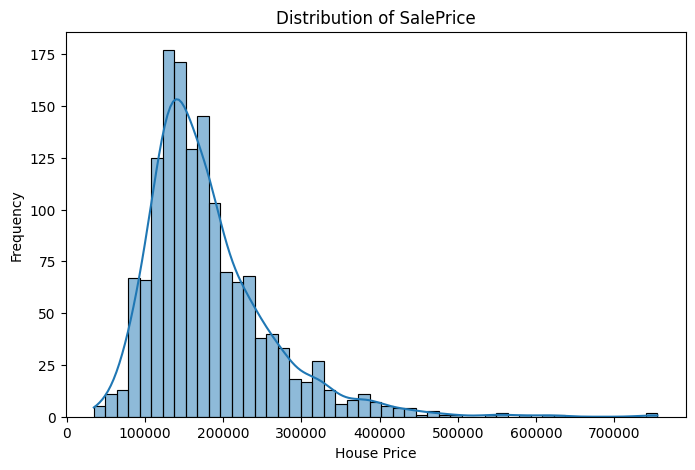

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(y, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

## Identifying Numerical and Categorical Features

The dataset contains two main types of variables:

- Numerical features: Variables that contain measurable quantities such as area, year, and counts.
- Categorical features: Variables that contain labels or categories such as neighborhood, house style, and exterior type.

I separate these feature types so that I can apply appropriate encoding methods.

In [54]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include="object"
).columns

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 37
Number of categorical features: 43


# Method 1: Label Encoding

Label Encoding converts categorical variables into numerical values by assigning a unique integer to each category.



This method is simple and reduces the number of columns. However, it may introduce artificial ordering between categories that do not have a natural ranking.

For this reason, the performance of Label Encoding will be compared with other encoding techniques.

In [58]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [59]:
from sklearn.model_selection import train_test_split

In [62]:
%%time

train = pd.DataFrame()

label = LabelEncoder()

for c in X.columns:
    if X[c].dtype == 'object':
        train[c] = label.fit_transform(X[c].astype(str))
    else:
        train[c] = X[c]

print(train.head(5))

   Id  MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  LotShape  \
0   1          60         3         65.0     8450       1      1         3   
1   2          20         3         80.0     9600       1      1         3   
2   3          60         3         68.0    11250       1      1         0   
3   4          70         3         60.0     9550       1      1         0   
4   5          60         3         84.0    14260       1      1         0   

   LandContour  Utilities  ...  ScreenPorch  PoolArea  PoolQC  Fence  \
0            3          0  ...            0         0       3      4   
1            3          0  ...            0         0       3      4   
2            3          0  ...            0         0       3      4   
3            3          0  ...            0         0       3      4   
4            3          0  ...            0         0       3      4   

   MiscFeature  MiscVal  MoSold  YrSold  SaleType  SaleCondition  
0            1        0       2

In [63]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   int64  
 6   Alley          1460 non-null   int64  
 7   LotShape       1460 non-null   int64  
 8   LandContour    1460 non-null   int64  
 9   Utilities      1460 non-null   int64  
 10  LotConfig      1460 non-null   int64  
 11  LandSlope      1460 non-null   int64  
 12  Neighborhood   1460 non-null   int64  
 13  Condition1     1460 non-null   int64  
 14  Condition2     1460 non-null   int64  
 15  BldgType       1460 non-null   int64  
 16  HouseStyle     1460 non-null   int64  
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Training a Model Using Label Encoding

After applying Label Encoding, I will train a machine learning model using the encoded features.

I will split the encoded dataset into training and validation sets. The training data will be used to learn the relationship between the house characteristics and `SalePrice`, while the validation data will be used to evaluate the model on unseen observations.

I will use Root Mean Squared Error (RMSE) to evaluate the model. A lower RMSE indicates that the model's predictions are closer to the actual house prices.

In [64]:
from sklearn.model_selection import train_test_split

X_label = train
y_label = y

X_train, X_valid, y_train, y_valid = train_test_split(
    X_label,
    y_label,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_valid.shape)

Training set: (1168, 80)
Validation set: (292, 80)


## Random Forest Model with Label Encoding

I will use a Random Forest Regressor to evaluate the performance of the Label Encoded features.

Random Forest is suitable for this dataset because it can model nonlinear relationships between house characteristics and the sale price.

In [78]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def random_forest(X, y):
    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y,
        random_state=42,
        test_size=0.2
    )

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_valid)

    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

    print("RMSE:", rmse)
    return rmse

In [79]:
label_rmse=random_forest(train, y)

RMSE: 28593.676100132583


## Method 2: One-Hot Encoding

I will use One-Hot Encoding to convert the categorical variables into numerical variables.

Unlike Label Encoding, which assigns an integer to each category, One-Hot Encoding creates a separate binary column for each category.

I will use One-Hot Encoding to avoid introducing an artificial numerical order between categories. After encoding the data, I will evaluate it using the same Random Forest Regressor and RMSE metric used for Label Encoding.

In [87]:
%%time

from sklearn.preprocessing import OneHotEncoder

one=OneHotEncoder(handle_unknown='ignore')

one.fit(X)
train=one.transform(X)

print('train data set has got {} rows and {} columns'.format(train.shape[0],train.shape[1]))

train data set has got 1460 rows and 9103 columns
CPU times: user 73.9 ms, sys: 2.04 ms, total: 76 ms
Wall time: 73.7 ms


### Checking the One-Hot Encoded Dataset

After applying One-Hot Encoding, I will check the shape of the dataset to see how the number of features has changed.

One-Hot Encoding usually increases the number of columns because each category is represented by a separate binary feature.

In [81]:
print("Original number of features:", X.shape[1])
print("Number of features after One-Hot Encoding:", X_onehot.shape[1])

Original number of features: 80
Number of features after One-Hot Encoding: 303


### Checking for Missing Values

I will check whether any missing values remain after applying One-Hot Encoding.

The dataset should contain no missing values because I handled the missing numerical and categorical values before applying the encoding techniques.

In [88]:
onehot_rmse = random_forest(X_onehot, y)

RMSE: 28868.67576754654


### One-Hot Encoding Results

The Random Forest model produced an RMSE of the value shown above when using One-Hot Encoding.

I will compare this value with the RMSE obtained from Label Encoding to determine which encoding technique performed better on this dataset.

A lower RMSE indicates better prediction performance.

In [89]:
print("Label Encoding RMSE:",label_rmse)
print("One-Hot Encoding RMSE:", onehot_rmse)

Label Encoding RMSE: 28593.676100132583
One-Hot Encoding RMSE: 28868.67576754654


## Method 3: Feature Hashing

I will use Feature Hashing to transform the categorical variables into numerical features.

Feature Hashing converts categorical values into a fixed number of numerical features using a hashing function. This can reduce the number of columns compared with One-Hot Encoding, especially when categorical variables contain many unique categories.

I will then use the same Random Forest Regressor and RMSE evaluation method so that the results can be compared fairly with Label Encoding and One-Hot Encoding.

In [91]:
data = X[categorical_features].to_dict('records')

print(data[:5])

[{'MSZoning': 'RL', 'Street': 'Pave', 'Alley': 'None', 'LotShape': 'Reg', 'LandContour': 'Lvl', 'Utilities': 'AllPub', 'LotConfig': 'Inside', 'LandSlope': 'Gtl', 'Neighborhood': 'CollgCr', 'Condition1': 'Norm', 'Condition2': 'Norm', 'BldgType': '1Fam', 'HouseStyle': '2Story', 'RoofStyle': 'Gable', 'RoofMatl': 'CompShg', 'Exterior1st': 'VinylSd', 'Exterior2nd': 'VinylSd', 'MasVnrType': 'BrkFace', 'ExterQual': 'Gd', 'ExterCond': 'TA', 'Foundation': 'PConc', 'BsmtQual': 'Gd', 'BsmtCond': 'TA', 'BsmtExposure': 'No', 'BsmtFinType1': 'GLQ', 'BsmtFinType2': 'Unf', 'Heating': 'GasA', 'HeatingQC': 'Ex', 'CentralAir': 'Y', 'Electrical': 'SBrkr', 'KitchenQual': 'Gd', 'Functional': 'Typ', 'FireplaceQu': 'None', 'GarageType': 'Attchd', 'GarageFinish': 'RFn', 'GarageQual': 'TA', 'GarageCond': 'TA', 'PavedDrive': 'Y', 'PoolQC': 'None', 'Fence': 'None', 'MiscFeature': 'None', 'SaleType': 'WD', 'SaleCondition': 'Normal'}, {'MSZoning': 'RL', 'Street': 'Pave', 'Alley': 'None', 'LotShape': 'Reg', 'LandCon

In [92]:
from sklearn.feature_extraction import FeatureHasher

hasher = FeatureHasher(n_features=20, input_type='dict')

train = hasher.transform(data)

print('train data set has got {} rows and {} columns'.format(
    train.shape[0],
    train.shape[1]
))

train data set has got 1460 rows and 20 columns


## Evaluating Feature Hashing

I will now use the Feature Hashed data to train a Random Forest Regressor.

I will use RMSE to measure the model's performance. A lower RMSE indicates that the model's predictions are closer to the actual house prices.

In [93]:
hash_rmse = random_forest(train, y)

RMSE: 56113.82803047692


In [94]:
print("Label Encoding RMSE:", label_rmse)
print("One-Hot Encoding RMSE:", onehot_rmse)
print("Feature Hashing RMSE:", hash_rmse)

Label Encoding RMSE: 28593.676100132583
One-Hot Encoding RMSE: 28868.67576754654
Feature Hashing RMSE: 56113.82803047692


## Method 4: Encoding Categories with Dataset Statistics

I will replace each category with the number of times it appears in the dataset.

This gives each category a numerical representation while keeping the number of columns small. Categories that occur frequently will receive higher values, while categories that occur less frequently will receive lower values.

This method allows me to represent categorical variables numerically without creating a large number of new columns.

In [95]:
%%time

train = X.copy()

for col in categorical_features:
    counts = X[col].value_counts()
    train[col] = X[col].map(counts)

train.head(5)

CPU times: user 46.8 ms, sys: 4.93 ms, total: 51.7 ms
Wall time: 49.5 ms


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,1151,65.0,8450,1454,1369,925,1311,1459,...,0,0,1453,1179,1406,0,2,2008,1267,1198
1,2,20,1151,80.0,9600,1454,1369,925,1311,1459,...,0,0,1453,1179,1406,0,5,2007,1267,1198
2,3,60,1151,68.0,11250,1454,1369,484,1311,1459,...,0,0,1453,1179,1406,0,9,2008,1267,1198
3,4,70,1151,60.0,9550,1454,1369,484,1311,1459,...,0,0,1453,1179,1406,0,2,2006,1267,101
4,5,60,1151,84.0,14260,1454,1369,484,1311,1459,...,0,0,1453,1179,1406,0,12,2008,1267,1198


## Cyclic Features

I will encode the month of sale as a cyclic feature because months are cyclical.

For example, December and January are close to each other in time even though their numerical values are far apart.

I will use sine and cosine transformations to represent the cyclical relationship between the months.

In [96]:
import numpy as np

train['MoSold_sin'] = np.sin(2 * np.pi * train['MoSold'] / 12)
train['MoSold_cos'] = np.cos(2 * np.pi * train['MoSold'] / 12)

train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,MoSold_sin,MoSold_cos
0,1,60,1151,65.0,8450,1454,1369,925,1311,1459,...,1453,1179,1406,0,2,2008,1267,1198,8.660254e-01,5.000000e-01
1,2,20,1151,80.0,9600,1454,1369,925,1311,1459,...,1453,1179,1406,0,5,2007,1267,1198,5.000000e-01,-8.660254e-01
2,3,60,1151,68.0,11250,1454,1369,484,1311,1459,...,1453,1179,1406,0,9,2008,1267,1198,-1.000000e+00,-1.836970e-16
3,4,70,1151,60.0,9550,1454,1369,484,1311,1459,...,1453,1179,1406,0,2,2006,1267,101,8.660254e-01,5.000000e-01
4,5,60,1151,84.0,14260,1454,1369,484,1311,1459,...,1453,1179,1406,0,12,2008,1267,1198,-2.449294e-16,1.000000e+00


In [98]:
statistics_rmse = random_forest(train, y)

RMSE: 28671.289799013717


## Method 5: Target Encoding

I will replace each category with the average `SalePrice` associated with that category.

This allows the categorical variables to be represented using a single numerical column while incorporating information about the target variable.

In [99]:
%%time

train = X.copy()

for col in categorical_features:
    means = df_train.groupby(col)['SalePrice'].mean()
    train[col] = X[col].map(means)

train.head(5)

CPU times: user 58.2 ms, sys: 32 µs, total: 58.2 ms
Wall time: 57.6 ms


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,191004.994787,65.0,8450,181130.538514,NaN,164754.818378,180183.746758,180950.95682,...,0,0,NaN,NaN,NaN,0,2,2008,173401.836622,175202.219533
1,2,20,191004.994787,80.0,9600,181130.538514,NaN,164754.818378,180183.746758,180950.95682,...,0,0,NaN,NaN,NaN,0,5,2007,173401.836622,175202.219533
2,3,60,191004.994787,68.0,11250,181130.538514,NaN,206101.665289,180183.746758,180950.95682,...,0,0,NaN,NaN,NaN,0,9,2008,173401.836622,175202.219533
3,4,70,191004.994787,60.0,9550,181130.538514,NaN,206101.665289,180183.746758,180950.95682,...,0,0,NaN,NaN,NaN,0,2,2006,173401.836622,146526.623762
4,5,60,191004.994787,84.0,14260,181130.538514,NaN,206101.665289,180183.746758,180950.95682,...,0,0,NaN,NaN,NaN,0,12,2008,173401.836622,175202.219533


In [100]:
target_rmse = random_forest(train, y)

RMSE: 28618.589644811538


## Method 6: K-Fold Target Encoding

I will use K-Fold Target Encoding to reduce the risk of target leakage when encoding categorical variables.

The training data will be divided into several folds. The target-based statistics for each observation will be calculated using the other folds rather than the observation's own target value.

This helps create a more reliable target encoding that can generalize better to unseen data.

In [104]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train = X.copy()

for col in categorical_features:
    train[col] = 0.0
    
    for train_idx, valid_idx in kf.split(X):
        
        X_fold = X.iloc[train_idx]
        y_fold = y.iloc[train_idx]
        
        means = pd.DataFrame({
            col: X_fold[col],
            'SalePrice': y_fold
        }).groupby(col)['SalePrice'].mean()
        
        encoded = X.iloc[valid_idx][col].map(means)
        
        # Use the overall training-fold mean for unseen categories
        encoded = encoded.fillna(y_fold.mean())
        
        train.iloc[valid_idx, train.columns.get_loc(col)] = encoded

In [105]:
print(train.shape)
print(train.isnull().sum().sum())

(1460, 80)
0


In [106]:
kfold_rmse = random_forest(train, y)

RMSE: 29118.226493414142


## Summary of Model Performance

I will compare the Random Forest Regressor performance across all the encoding techniques.

I will use RMSE as the evaluation metric. A lower RMSE indicates better model performance because it means the predictions are closer to the actual house prices.

In [107]:
print("Label Encoding RMSE:", label_rmse)
print("One-Hot Encoding RMSE:", onehot_rmse)
print("Feature Hashing RMSE:", hash_rmse)
print("Dataset Statistics RMSE:", statistics_rmse)
print("Target Encoding RMSE:", target_rmse)
print("K-Fold Target Encoding RMSE:", kfold_rmse)

Label Encoding RMSE: 28593.676100132583
One-Hot Encoding RMSE: 28868.67576754654
Feature Hashing RMSE: 56113.82803047692
Dataset Statistics RMSE: 28671.289799013717
Target Encoding RMSE: 28618.589644811538
K-Fold Target Encoding RMSE: 29118.226493414142


## Final Comparison of Encoding Techniques

After applying the different encoding techniques and training a Random Forest Regressor, I compared their performance using RMSE.

The results were:

- **Label Encoding:** 28,593.68
- **Target Encoding:** 28,618.59
- **Dataset Statistics:** 28,671.29
- **One-Hot Encoding:** 28,868.68
- **K-Fold Target Encoding:** 29,118.23
- **Feature Hashing:** 56,113.83

Since a lower RMSE indicates better predictive performance, Label Encoding achieved the best result with an RMSE of 28,593.68.

Target Encoding and Dataset Statistics also performed relatively well, with RMSE values close to Label Encoding.

One-Hot Encoding performed slightly worse than Label Encoding, while K-Fold Target Encoding produced a higher RMSE in this experiment.

Feature Hashing performed considerably worse than the other encoding techniques, with an RMSE of 56,113.83.

Therefore, based on this experiment, I would select **Label Encoding** as the best-performing encoding technique for the Random Forest model on this dataset.